<a href="https://colab.research.google.com/github/nehasmane2003-stack/MACHINE-LEARNING-Clg/blob/main/Ass_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Naive Bayes classifier

## Task
Analyze the Pima Indians Diabetes dataset from "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv" by training a Naive Bayes classifier, evaluating its accuracy, visualizing a confusion matrix, and summarizing its performance.

## Load Dataset

### Subtask:
Load the Pima Indians Diabetes dataset from the provided URL into a pandas DataFrame.


**Reasoning**:
Import the pandas library and load the dataset from the provided URL into a DataFrame, then display the first few rows to verify the load.



In [ ]:
import pandas as pd

# Define the URL for the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'

# Load the dataset from the URL into a DataFrame
df = pd.read_csv(url, header=None)

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   0    1   2   3    4     5      6   7  8
0  6  148  72  35    0  33.6  0.627  50  1
1  1   85  66  29    0  26.6  0.351  31  0
2  8  183  64   0    0  23.3  0.672  32  1
3  1   89  66  23   94  28.1  0.167  21  0
4  0  137  40  35  168  43.1  2.288  33  1


## Prepare Data

### Subtask:
Separate the features (X) and the target variable (y) from the dataset. The target variable is the last column indicating diabetes status.


**Reasoning**:
Separate the features (X) and the target variable (y) from the DataFrame `df` according to the instructions.



In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("First 5 rows of features (X):")
print(X.head())

print("\nFirst 5 rows of target variable (y):")
print(y.head())

First 5 rows of features (X):
   0    1   2   3    4     5      6   7
0  6  148  72  35    0  33.6  0.627  50
1  1   85  66  29    0  26.6  0.351  31
2  8  183  64   0    0  23.3  0.672  32
3  1   89  66  23   94  28.1  0.167  21
4  0  137  40  35  168  43.1  2.288  33

First 5 rows of target variable (y):
0    1
1    0
2    1
3    0
4    1
Name: 8, dtype: int64


## Split Data

### Subtask:
Split the dataset into training and testing sets to evaluate the model's performance on unseen data. A common split is 80% for training and 20% for testing.


**Reasoning**:
To split the dataset into training and testing sets, I will import the `train_test_split` function from `sklearn.model_selection` and apply it to the features (X) and target variable (y) with a 80/20 split and a fixed random state for reproducibility.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


## Train Naive Bayes Classifier

### Subtask:
Initialize and train a Gaussian Naive Bayes classifier using the training data.


**Reasoning**:
To initialize and train a Gaussian Naive Bayes classifier, I will import the `GaussianNB` class, instantiate it, and then use the `fit` method with the training data (`X_train`, `y_train`).



In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes classifier
model = GaussianNB()

# Train the model using the training data
model.fit(X_train, y_train)

print("Gaussian Naive Bayes classifier trained successfully.")

Gaussian Naive Bayes classifier trained successfully.


## Make Predictions

### Subtask:
Use the trained Naive Bayes classifier to make predictions on the test set.


**Reasoning**:
To make predictions, I will use the trained `model`'s `predict` method on `X_test` and store the results in `y_pred`, then display the first five predictions.



In [ ]:
y_pred = model.predict(X_test)

print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
[0 0 0 0 1]


## Evaluate Model Performance

### Subtask:
Calculate and print the accuracy of the Naive Bayes classifier on the test set.

**Reasoning**:
To calculate the accuracy, I will import the `accuracy_score` metric from `sklearn.metrics` and use it to compare the true labels (`y_test`) with the predicted labels (`y_pred`).



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Accuracy of the Naive Bayes classifier: {accuracy:.4f}")

Accuracy of the Naive Bayes classifier: 0.7662


## Visualize Confusion Matrix

### Subtask:
Generate and display a confusion matrix for the Naive Bayes classifier's predictions on the test set. Also, provide a classification report.


**Reasoning**:
To generate the confusion matrix and classification report, I will import the necessary functions from `sklearn.metrics`, compute them using `y_test` and `y_pred`, and then visualize the confusion matrix using `seaborn` and `matplotlib.pyplot` and print the classification report.



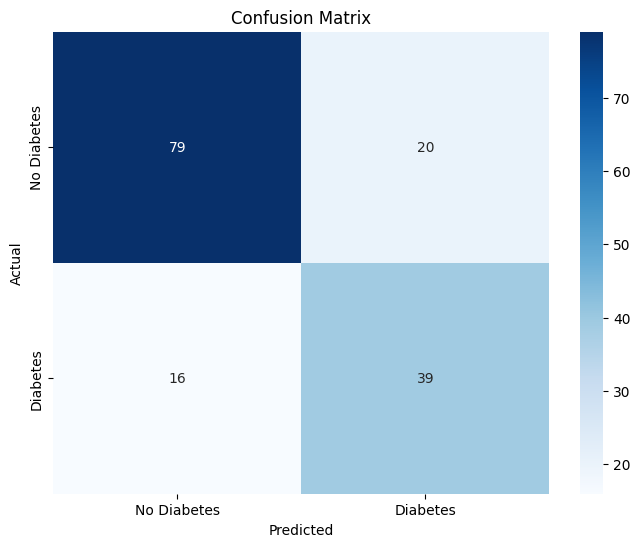


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))